
--- 外部要因データの処理を開始 ---
→ ドイツ電動車全体販売台数を読み込み中...
→ Japanの経済指標を読み込み中...
→ Germany_Econの経済指標を読み込み中...
→ Trends_EV_GeneralのGoogleトレンドデータを読み込み中...
→ Trends_Toyota_WebのGoogleトレンドデータを読み込み中...
→ Trends_Toyota_YTのGoogleトレンドデータを読み込み中...
→ 最終的な外部要因特徴量数: 236
--- 外部要因データの処理を完了 ---
--- 訓練データ形状: (34, 12, 241) (サンプル数, Look_Back, 特徴量数) ---


C:\Users\ciao0\AppData\Local\Temp\ipykernel_7084\3435363521.py:249: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trends_df["年月"] = pd.to_datetime(date_series, errors="coerce")
C:\Users\ciao0\AppData\Local\Temp\ipykernel_7084\3435363521.py:249: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trends_df["年月"] = pd.to_datetime(date_series, errors="coerce")
C:\Users\ciao0\AppData\Local\Temp\ipykernel_7084\3435363521.py:288: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_external_df[f


--- モデル学習開始 ---
--- モデル学習完了: 76 エポックで停止しました。---

--- 予測期間 ---
訓練期間: 2020-01-01 から 2023-12-31
テスト期間: 2024-01-01 から 2024-12-31

---トヨタ（全車種合計）の月次予測結果---
| 年月       |   予測販売台数 |
|:-----------|---------------:|
| 2024年01月 |           5527 |
| 2024年02月 |           5645 |
| 2024年03月 |           5794 |
| 2024年04月 |           6280 |
| 2024年05月 |           6071 |
| 2024年06月 |           6524 |
| 2024年07月 |           6826 |
| 2024年08月 |           6839 |
| 2024年09月 |           6884 |
| 2024年10月 |           6931 |
| 2024年11月 |           7023 |
| 2024年12月 |           7781 |


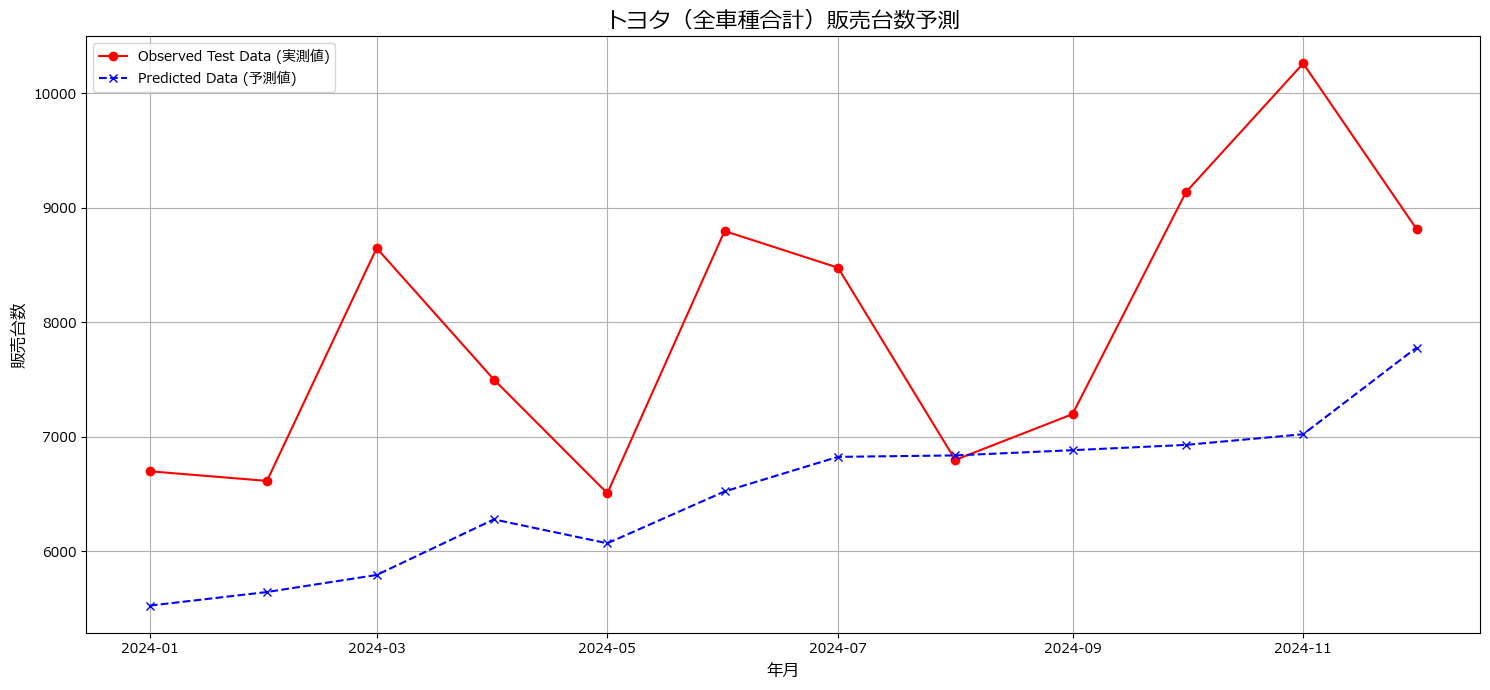


--- 予測性能評価 ---
MAE (平均絶対誤差): 1451.44
RMSE (二乗平均平方根誤差): 1745.99
MAPE (平均絶対パーセント誤差): 17.16%


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import tensorflow as tf
import random
import re
import unicodedata
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tabulate import tabulate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 乱数シードを固定
SEED = 0
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.keras.backend.clear_session()

# --- フォント設定 ---
# Windows環境を想定。適切なフォントパスに変更してください。
font_path = "C:/Windows/Fonts/meiryo.ttc"
if os.path.exists(font_path):
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False 

# --- ファイルパス ---
# 予測対象データを「トヨタ販売台数＿全体.csv」
car_file_path = "トヨタ販売台数＿全体.csv" 
econ_file_path_japan = "経済指標＿日本.csv"
econ_file_path_germany = "経済指標＿ドイツ.csv"
google_trends_file_path_1 = "Googleトレンド.csv"
germany_car_file_path = "ドイツ＿電動車全体.csv"
toyota_web_trends_path = "toyota_all_web.csv"
toyota_youtube_trends_path = "toyota_all_youtube.csv"


# --- データのロードと前処理 ---
def load_and_preprocess_car_data_total_sales(file_path):
    """すべての車種の販売台数合計を整形する関数"""
    try:
        df = pd.read_csv(file_path, encoding="cp932")
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="utf-8")
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。ファイル名を確認してください。")
        return pd.DataFrame()

    df.columns = df.columns.astype(str)
    # 年月を示すカラム（例: '202001'）を抽出
    date_cols = [col for col in df.columns if str(col).isdigit() and len(str(col)) == 6]
    
    # IDカラムを特定
    id_cols = [col for col in ["モデル", "パワー", "グループ", "メーカー・ブランド", "国", "車種", "セグメント", "パワートレイン"] if col in df.columns]
    
    # もし特定のIDカラムが見つからない場合は最初のカラムを使用
    if not id_cols and df.shape[1] > len(date_cols):
        id_cols = [df.columns[0]] 
    elif not id_cols:
        print("エラー: 販売台数データのIDカラムが見つかりませんでした。")
        return pd.DataFrame()

    # データをロングフォーマットに変換
    long_df = df.melt(id_vars=id_cols, value_vars=date_cols, var_name="年月", value_name="販売台数")
    
    # 日付のパースとクリーンアップ
    long_df["年月"] = pd.to_datetime(long_df["年月"], format="%Y%m", errors="coerce")
    long_df = long_df.dropna(subset=["年月"])
    
    # 販売台数の文字列を数値に変換 (ハイフンなどを除去)
    long_df["販売台数"] = long_df["販売台数"].astype(str).str.replace(r'[^0-9\.-]', '', regex=True)
    long_df["販売台数"] = pd.to_numeric(long_df["販売台数"], errors="coerce").fillna(0)
    
    # 全車種の販売台数を合計
    all_car_sales_df = long_df.groupby("年月")["販売台数"].sum().to_frame()
    # 月初にリサンプリング
    all_car_sales_df = all_car_sales_df.resample('MS').sum()
    
    # --- 変更点: ラグ特徴量を1, 2, 3ヶ月前に変更 ---
    all_car_sales_df['販売台数_lag1'] = all_car_sales_df['販売台数'].shift(1)
    all_car_sales_df['販売台数_lag2'] = all_car_sales_df['販売台数'].shift(2)
    all_car_sales_df['販売台数_lag3'] = all_car_sales_df['販売台数'].shift(3)
    
    all_car_sales_df = all_car_sales_df.dropna() # 最大ラグ期間（3ヶ月）に基づいて最初の数行がドロップされる
    
    return all_car_sales_df

def load_and_preprocess_external_data(car_sales_df):
    """経済指標、Googleトレンドデータ（3種）、およびドイツ電動車全体販売台数を読み込み、整形・結合する関数"""
    combined_external_df = pd.DataFrame(index=car_sales_df.index)
    print("\n--- 外部要因データの処理を開始 ---")

    # 1. ドイツ電動車全体販売台数の処理 (ドイツ＿電動車全体.csv)
    print(f"→ ドイツ電動車全体販売台数を読み込み中...")
    try:
        germany_car_df = pd.read_csv(germany_car_file_path, encoding="cp932")
    except:
        try:
            germany_car_df = pd.read_csv(germany_car_file_path, encoding="utf-8")
        except:
            print(f"注意: ドイツ電動車全体ファイル '{germany_car_file_path}' の読み込みに失敗しました。スキップします。")
            germany_car_df = None

    if germany_car_df is not None and not germany_car_df.empty:
        germany_car_df.columns = germany_car_df.columns.astype(str).str.strip()
        germany_date_cols = [col for col in germany_car_df.columns if str(col).isdigit() and len(col) == 6]
        
        germany_sales_df_temp = germany_car_df[germany_date_cols].replace('-', np.nan).apply(pd.to_numeric, errors='coerce').fillna(0)
        germany_sales = germany_sales_df_temp.sum()
        
        germany_sales.index = pd.to_datetime(germany_sales.index, format="%Y%m", errors="coerce")
        germany_sales_df = germany_sales.rename("Germany_Total_EV_Sales").to_frame()
        germany_sales_df = germany_sales_df.resample('MS').sum()
        germany_sales_df = germany_sales_df.dropna()
        
        combined_external_df = pd.merge(combined_external_df, germany_sales_df, left_index=True, right_index=True, how="outer")
        combined_external_df.fillna(0, inplace=True)


    # 2. 経済指標データの処理 (経済指標＿日本.csv, 経済指標＿ドイツ.csv)
    econ_file_paths = {
        'Japan': econ_file_path_japan,
        'Germany_Econ': econ_file_path_germany
    }
    for country, file_path in econ_file_paths.items():
        print(f"→ {country}の経済指標を読み込み中...")
        try:
            try:
                econ_df = pd.read_csv(file_path, encoding="cp932")
            except:
                econ_df = pd.read_csv(file_path, encoding="utf-8")
        except FileNotFoundError:
            print(f"注意: 経済指標ファイル '{file_path}' が見つかりません。スキップします。")
            continue
        except Exception as e:
            print(f"注意: 経済指標ファイル '{file_path}' の読み込みに失敗しました ({e})。スキップします。")
            continue

        if econ_df.empty:
            continue
            
        original_col_name = econ_df.columns[0]
        econ_df.rename(columns={original_col_name: "DATE_COL"}, inplace=True)

        date_str = econ_df["DATE_COL"].astype(str).str.replace(r'[^0-9]', '', regex=True).str[:6]
        econ_df["年月"] = pd.to_datetime(date_str, format="%Y%m", errors="coerce")
        econ_df = econ_df.dropna(subset=["年月"])
        
        if econ_df.empty:
            print(f"警告: {country}の経済指標で有効な日付がパースできませんでした。スキップします。")
            continue

        econ_df = econ_df.set_index("年月").sort_index()

        all_econ_features = [col for col in econ_df.columns if col not in ['DATE_COL', '年月']]
        econ_df = econ_df[all_econ_features]
        
        for col in econ_df.columns:
            econ_df[col] = pd.to_numeric(econ_df[col], errors='coerce')
        
        econ_df = econ_df.ffill().bfill().fillna(0)
        econ_df = econ_df.add_prefix(f'{country}_')

        combined_external_df = pd.merge(combined_external_df, econ_df, left_index=True, right_index=True, how="outer")

    # 3. Googleトレンドデータの処理 (3種)
    trends_file_paths = {
        'Trends_EV_General': google_trends_file_path_1,     # Googleトレンド.csv (header=0)
        'Trends_Toyota_Web': toyota_web_trends_path,        # toyota_all_web.csv (header=2)
        'Trends_Toyota_YT': toyota_youtube_trends_path      # toyota_all_youtube.csv (header=2)
    }
    
    # 月名略記から数値へのマッピングを定義
    MONTH_MAP = {
        'jan': '01', 'feb': '02', 'mar': '03', 'apr': '04', 'may': '05', 'jun': '06',
        'jul': '07', 'aug': '08', 'sep': '09', 'oct': '10', 'nov': '11', 'dec': '12'
    }

    for prefix, file_path in trends_file_paths.items():
        print(f"→ {prefix}のGoogleトレンドデータを読み込み中...")
        
        header_to_use = 0 if prefix == 'Trends_EV_General' else 2
        
        try:
            trends_df = pd.read_csv(file_path, encoding="cp932", header=header_to_use)
        except:
            try:
                trends_df = pd.read_csv(file_path, encoding="utf-8", header=header_to_use)
            except:
                print(f"注意: トレンドファイル '{file_path}' の読み込みに失敗しました。スキップします。")
                continue
            
        # 1. 最初のカラム名自体をクリーンアップし、確実に'年月_str'にリネーム
        first_col_name = trends_df.columns[0]
        cleaned_first_col_name = unicodedata.normalize('NFKC', str(first_col_name)).strip()
        
        # 確実にカラム名を置き換える
        trends_df.rename(columns={first_col_name: '年月_str'}, inplace=True)

        # 2. Date series preparation: データの文字列クリーンアップ
        date_series = trends_df["年月_str"].astype(str).apply(lambda x: unicodedata.normalize('NFKC', x).strip())
        trends_df["年月"] = pd.NaT 
        
        # 3. Trends_Toyota_YT向け：Mon-YY形式のロバスト変換 + YYYYMM形式のフォールバック
        if prefix == 'Trends_Toyota_YT':
            
            # Mon-YY (Jan-20) -> YYYYMM (202001) 形式に文字列変換する関数
            def convert_mon_yy_to_yyyymm_final(date_str):
                # 数字、ハイフン、英字以外を全て削除（非表示文字対策）
                date_str_clean = re.sub(r'[^\w-]', '', date_str).lower()
                
                parts = date_str_clean.split('-')
                
                if len(parts) == 2 and parts[0] in MONTH_MAP:
                    try:
                        month = MONTH_MAP[parts[0]]
                        year_two_digit = parts[1]
                        # YYYYMM形式に変換 (20xx年に固定)
                        year = '20' + year_two_digit
                        return f'{year}{month}'
                    except:
                        return None
                return None
            
            # 3-A. Mon-YY形式を試す
            trends_df["年月_pre"] = date_series.apply(convert_mon_yy_to_yyyymm_final)
            trends_df["年月"] = pd.to_datetime(trends_df["年月_pre"], format="%Y%m", errors="coerce")
            
            # 3-B. 失敗した場合、YYYYMM形式を試す (e.g., '202001' or '202001-01')
            mask_nan = trends_df["年月"].isna()
            if mask_nan.any():
                # YYYYMM形式に合うように文字列を整理
                date_part_ym = date_series.loc[mask_nan].str.replace(r'[^0-9]', '', regex=True).str[:6]
                valid_ym_mask = date_part_ym.str.len() == 6
                trends_df.loc[mask_nan & valid_ym_mask, "年月"] = pd.to_datetime(date_part_ym.loc[mask_nan & valid_ym_mask], format="%Y%m", errors="coerce")
                
            trends_df.drop(columns=["年月_pre"], inplace=True, errors='ignore') # 一時カラム削除
            
        else: # その他のトレンドデータ (YYYY-MM, YYYY/MM, YYYYMM)
            
            # 1. YYYY-MM / YYYY/MM (汎用)を試す
            trends_df["年月"] = pd.to_datetime(date_series, errors="coerce")
            
            # 2. YYYYMM 形式を試す (e.g., '202001')
            mask_nan = trends_df["年月"].isna()
            if mask_nan.any():
                # YYYYMM形式に合うように文字列を整理
                date_part_ym = date_series.loc[mask_nan].str.replace(r'[^0-9]', '', regex=True).str[:6]
                valid_ym_mask = date_part_ym.str.len() == 6
                trends_df.loc[mask_nan & valid_ym_mask, "年月"] = pd.to_datetime(date_part_ym.loc[mask_nan & valid_ym_mask], format="%Y%m", errors="coerce")
        
        # 最終チェック
        trends_df = trends_df.dropna(subset=["年月"])
        
        if trends_df.empty:
            print(f"警告: {prefix}で有効な日付がパースできませんでした。スキップします。")
            continue

        trends_df = trends_df.set_index("年月").sort_index()
        
        # 文字列の日付カラムを削除
        trends_df = trends_df.drop(columns=['年月_str'], errors='ignore')

        # 不要なカラムを削除し、一意なプレフィックスを付与
        trends_df = trends_df.loc[:, ~trends_df.columns.str.contains(':')] 
        trends_df = trends_df.loc[:, ~trends_df.columns.duplicated(keep='first')] 

        trends_df = trends_df.add_prefix(f'{prefix}_')
        
        # 数値変換
        for col in trends_df.columns:
            trends_df[col] = pd.to_numeric(trends_df[col], errors='coerce').fillna(0)
        
        combined_external_df = pd.merge(combined_external_df, trends_df, left_index=True, right_index=True, how="outer")
        
    # 4. シンプルな特徴量エンジニアリング（ラグ特徴量の追加）と最終クリーンアップ
    combined_external_df = combined_external_df.ffill().bfill().fillna(0)

    final_external_df = pd.DataFrame(index=car_sales_df.index)
    for feature in combined_external_df.columns:
        final_external_df[feature] = combined_external_df[feature]
        final_external_df[f'{feature}_lag1'] = combined_external_df[feature].shift(1)
        final_external_df[f'{feature}_lag2'] = combined_external_df[feature].shift(2)
        final_external_df[f'{feature}_lag3'] = combined_external_df[feature].shift(3)

    final_external_df = pd.merge(pd.DataFrame(index=car_sales_df.index), final_external_df, left_index=True, right_index=True, how="inner")
    final_external_df = final_external_df.ffill().bfill().fillna(0)
    final_external_df = final_external_df.dropna(axis=1, how='all')

    print(f"→ 最終的な外部要因特徴量数: {len(final_external_df.columns)}")
    print("--- 外部要因データの処理を完了 ---")
    return final_external_df

# --- データセット作成（多変量） ---
def create_multivariate_dataset(data, look_back):
    X, y = [], []
    # data[:, 0] は目的変数である「販売台数」
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# --- データロードと結合 ---
car_df = load_and_preprocess_car_data_total_sales(car_file_path)
if car_df.empty:
    exit()

external_df = load_and_preprocess_external_data(car_df)

merged_df = pd.merge(car_df, external_df, left_index=True, right_index=True, how="inner")
merged_df = merged_df.ffill().bfill().fillna(0)
merged_df['month'] = merged_df.index.month

# --- トレーニング・テスト期間の定義 ---
train_start = '2020-01-01'
train_end = '2023-12-31'
test_start = '2024-01-01'
test_end = '2024-12-31'
look_back = 12

test_df_observed = merged_df.loc[test_start:merged_df.index.max()]
all_test_dates = pd.date_range(start=test_start, end=test_end, freq='MS')

# --- スケーリング ---
features_to_scale = list(merged_df.columns)
scaler = RobustScaler()
scaled_data = scaler.fit_transform(merged_df[features_to_scale])

# --- 訓練データセットの準備 ---
start_idx = merged_df.index.get_indexer([pd.to_datetime(train_start)], method='nearest')[0]
end_idx = merged_df.index.get_indexer([pd.to_datetime(train_end)], method='nearest')[0]
scaled_train_data = scaled_data[start_idx:end_idx + 1]

if len(scaled_train_data) <= look_back:
    print(f"エラー: 訓練データがルックバック期間 ({look_back}) より短いため、モデルを構築できません。期間設定を確認してください。")
    exit()

X_train, y_train = create_multivariate_dataset(scaled_train_data, look_back)
print(f"--- 訓練データ形状: {X_train.shape} (サンプル数, Look_Back, 特徴量数) ---")

# --- モデル構築 ---
learning_rate = 0.01

model = Sequential()
# 入力層: (look_back, 全特徴量数)
model.add(LSTM(260, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))) 
model.add(Dropout(0.2))
model.add(LSTM(140, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))) 
model.add(Dropout(0.2))
model.add(LSTM(60, activation='relu')) 
model.add(Dropout(0.1))
model.add(Dense(1)) # 出力は1ステップ先の販売台数のみ

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#外れ値に強いのは"huber"で振幅を大きくするのは"mse"
model.compile(optimizer=optimizer, loss='huber', metrics=['mae'])

# --- 早期停止（Early Stopping）の設定 ---
early_stopping = EarlyStopping(monitor='val_loss', patience=70, mode='min', restore_best_weights=True)

print("\n--- モデル学習開始 ---")
history = model.fit(
    X_train,
    y_train,
    epochs=300, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0 
)
print(f"--- モデル学習完了: {len(history.history['loss'])} エポックで停止しました。---")

# --- 予測の実行（多段階予測） ---
predicted_sales_list = []
# 予測の初期シークエンスは訓練データの最後の look_back 期間
input_sequence = scaled_train_data[-look_back:] 
num_features = scaled_train_data.shape[1]

for i in range(len(all_test_dates)):
    current_input = input_sequence.reshape(1, look_back, num_features)
    predicted_value_scaled = model.predict(current_input, verbose=0)
    
    # テスト期間の実測値がある場合は、目的変数以外の特徴量にはその実測値を使用
    if all_test_dates[i] in merged_df.index:
        # 目的変数（販売台数）以外の特徴量を取得
        next_features_data = scaled_data[merged_df.index.get_loc(all_test_dates[i]), 1:]
    else:
        # 実測値がない場合は、前のステップの特徴量を使用
        next_features_data = input_sequence[-1, 1:] 
    
    # 予測された販売台数と、実測（または推定）されたその他の特徴量を結合
    predicted_full_row = np.concatenate((predicted_value_scaled, next_features_data.reshape(1, -1)), axis=1)
    
    # 逆スケーリングを実行し、最初のカラム（販売台数）を取得
    predicted_sales_inv = scaler.inverse_transform(predicted_full_row)[:, 0]
    # 販売台数は非負であるべき
    predicted_sales_list.append(np.maximum(0, predicted_sales_inv[0]))

    # 次の予測のための入力シークエンスを作成
    next_month_data = np.concatenate([predicted_value_scaled[0], next_features_data])
    input_sequence = np.vstack([input_sequence[1:], next_month_data])

all_predicted_sales = np.array(predicted_sales_list)

# --- 結果の表示 ---
print("\n--- 予測期間 ---")
print(f"訓練期間: {train_start} から {train_end}")
print(f"テスト期間: {test_start} から {test_end}")

results_df = pd.DataFrame({
    "年月": all_test_dates.strftime('%Y年%m月'),
    "予測販売台数": all_predicted_sales.round().astype(int)
})

print("\n---トヨタ（全車種合計）の月次予測結果---")
print(tabulate(results_df, headers='keys', tablefmt='pipe', showindex=False))

# --- グラフの描画 ---
plt.figure(figsize=(15, 7))

# 実測値のプロット
observed_in_test_range = merged_df.loc[test_start:test_end]
if not observed_in_test_range.empty:
    plt.plot(observed_in_test_range.index, observed_in_test_range['販売台数'],
             label='Observed Test Data (実測値)', color='red', marker='o', linestyle='-')

# 予測値のプロット
plt.plot(all_test_dates, all_predicted_sales, label='Predicted Data (予測値)', color='blue', marker='x', linestyle='--')

plt.title(f'トヨタ（全車種合計）販売台数予測', fontsize=16)
plt.xlabel('年月', fontsize=12)
plt.ylabel('販売台数', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 予測性能評価 ---
# 実測値が存在する期間のみを評価対象とする
observed_in_test_range = merged_df.loc[test_start:test_end][['販売台数']].copy()
observed_in_test_range = observed_in_test_range.reindex(all_test_dates) # 予測期間に合わせてインデックスを揃える

mask = ~observed_in_test_range['販売台数'].isna()
y_true = observed_in_test_range.loc[mask, '販売台数'].values
y_pred = all_predicted_sales[mask]

if len(y_true) > 0:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE計算
    mape_temp = np.abs((y_true - y_pred) / y_true)
    mape_temp[y_true == 0] = 0 # ゼロ除算対策
    mape_temp = mape_temp[np.isfinite(mape_temp)]
    mape = np.mean(mape_temp) * 100

    print(f"\n--- 予測性能評価 ---")
    print(f"MAE (平均絶対誤差): {mae:.2f}")
    print(f"RMSE (二乗平均平方根誤差): {rmse:.2f}")
    print(f"MAPE (平均絶対パーセント誤差): {mape:.2f}%")
else:
    print("\n--- 予測性能評価 ---")
    print("テスト期間に実測値がないため、MAE/RMSEは算出しません。")

### 2. データの前処理と統合 ###
目的変数 (Global_Total_Sales) の形状: (67, 2)
Global_Total_Sales の先頭5行:
     date  Global_Total_Sales
0  202001              5487.0
1  202002              5946.0
2  202003              5339.0
3  202004              3779.0
4  202005              4196.0
統合後の初期データ形状: (67, 64)
最終的な特徴量の数: 62
--------------------------------------------------
### 3. 主成分分析 (PCA) の実行と次元削減 ###


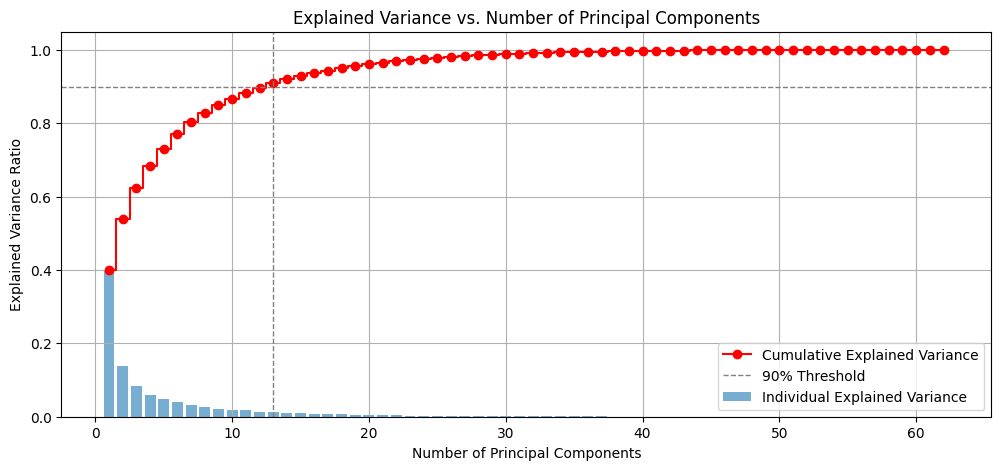

元の特徴量の数: 62
累積寄与率90%を達成するための主成分数: 13
採用した主成分の累積寄与率: 0.9101
--------------------------------------------------
### 予測モデルに使用するデータフレーム (特徴量は主成分) ###
             PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
date                                                                           
202001 -6.589713 -0.828189 -0.507666  1.968754  3.758437 -2.170125 -3.040701   
202002 -5.790722 -1.195099 -0.153263  2.318779  4.881676 -3.315862 -2.592194   
202003 -7.564173 -3.928339 -2.666410  1.004360  3.238960 -3.247378 -1.880386   
202004 -9.769110 -7.121833 -5.610427 -1.347858 -5.081757 -0.097608 -1.069678   
202005 -9.249728 -6.985542 -3.728034 -0.131445 -3.560369  0.711122 -0.250225   

             PC8       PC9      PC10      PC11      PC12      PC13  \
date                                                                 
202001  0.867124 -0.352216 -0.412164 -1.392168 -2.287476 -0.251589   
202002  0.815262 -1.068953 -0.505791  0.694311 -1.345429  0.457392   
202003 -0.262

In [2]:
#主成分分析
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. ライブラリのインポートとデータの読み込み
# ----------------------------------------

# 目的変数データ（トヨタ販売台数＿全体.csvを使用）
df_sales_raw = pd.read_csv('トヨタ販売台数＿全体.csv', encoding='cp932')

# 特徴量データ (説明変数) - 以前の会話で使用されたファイル名を想定
df_trend = pd.read_csv('Googleトレンド.csv', encoding='utf-8')
df_youtube = pd.read_csv('toyota_all_youtube.csv', encoding='utf-8')
df_web = pd.read_csv('toyota_all_web.csv', encoding='utf-8')
df_eco_de = pd.read_csv('経済指標＿ドイツ.csv', encoding='utf-8')
df_eco_jp = pd.read_csv('経済指標＿日本.csv', encoding='utf-8')
df_de_ev = pd.read_csv('ドイツ＿電動車全体.csv', encoding='utf-8') 

# ----------------------------------------
# 2. データの前処理と統合
# ----------------------------------------

print("### 2. データの前処理と統合 ###")

# --- 2-1. 目的変数 (Y: グローバル月間総販売台数) の整形 ---
# 日付列 (202001, ...) を特定
date_cols = [col for col in df_sales_raw.columns if col.isnumeric() and len(col) == 6]

# 販売台数部分のみ抽出して転置
sales_T = df_sales_raw[date_cols].T
sales_T.index.name = 'date'

# 全ての行（車種、国、パワートレイン）を合計して、月間総販売台数を計算
# まず数値型に変換し、非数値（"-"など）はNaNとして処理してから0に置換、行方向に合計
df_Y = sales_T.apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).to_frame(name='Global_Total_Sales').reset_index()
df_Y['date'] = df_Y['date'].astype(str)

print(f"目的変数 (Global_Total_Sales) の形状: {df_Y.shape}")
print(f"Global_Total_Sales の先頭5行:\n{df_Y.head()}")

# --- 2-2. 特徴量データ (説明変数X) の統合 ---
dfs = [df_trend, df_youtube, df_web, df_eco_de, df_eco_jp, df_de_ev]

df_merged = df_Y.copy()

for df in dfs:
    df['date'] = df['date'].astype(str)
    
    # 列名の重複を避ける処理
    cols_to_merge = [col for col in df.columns if col != 'date' and col not in df_merged.columns]
    
    # ドイツ電動車全体データ (df_de_ev) の 'sum' 列は 'DE_Total_EV_Sales' にリネーム
    if 'sum' in df.columns and df.equals(df_de_ev):
        df.rename(columns={'sum': 'DE_Total_EV_Sales'}, inplace=True)
        # リネームした列がcols_to_mergeに含まれていない場合があるため、再構築
        cols_to_merge = [col for col in df.columns if col != 'date' and col not in df_merged.columns]

    # 'date'をキーに結合
    df_merged = pd.merge(df_merged, df[['date'] + cols_to_merge], on='date', how='inner')

# 特徴量Xを抽出 (Global_Total_Salesとdate列を除外)
X_features = df_merged.drop(columns=['date', 'Global_Total_Sales'])
feature_names = X_features.columns

# 欠損値の処理 (平均値で補完)
X_features = X_features.fillna(X_features.mean())
X = X_features.values

print(f"統合後の初期データ形状: {df_merged.shape}")
print(f"最終的な特徴量の数: {X.shape[1]}")
print("-" * 50)


# ----------------------------------------
# 3. 主成分分析 (PCA) の実行と次元削減
# ----------------------------------------

print("### 3. 主成分分析 (PCA) の実行と次元削減 ###")

# --- 3-1. データの標準化 ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3-2. 全ての主成分を計算し、寄与率を分析 ---
pca_full = PCA()
pca_full.fit(X_scaled)

# 累積寄与率を計算
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 累積寄与率が90%を超える主成分数を特定
try:
    n_components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
except IndexError:
    n_components_90 = X.shape[1]

# --- 3-3. 寄与率の可視化 ---
plt.figure(figsize=(12, 5))
plt.bar(range(1, len(cumulative_variance) + 1), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual Explained Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative Explained Variance', color='red', marker='o')

plt.axvline(x=n_components_90, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=0.90, color='gray', linestyle='--', linewidth=1, label='90% Threshold')
plt.title('Explained Variance vs. Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()

print(f"元の特徴量の数: {X.shape[1]}")
print(f"累積寄与率90%を達成するための主成分数: {n_components_90}")
print(f"採用した主成分の累積寄与率: {cumulative_variance[n_components_90 - 1]:.4f}")
print("-" * 50)

# --- 3-4. 決定した主成分数で次元削減を実行 ---
n_components = n_components_90
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# ----------------------------------------
# 4. 予測モデルへの入力データの準備と保存
# ----------------------------------------

# PCA後の特徴量と目的変数を結合したデータフレームを作成
df_prediction = pd.DataFrame(
    X_pca, 
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=df_merged['date']
)
df_prediction['Global_Total_Sales'] = df_merged['Global_Total_Sales'].values

print("### 予測モデルに使用するデータフレーム (特徴量は主成分) ###")
print(df_prediction.head())
output_file_name = '主成分分析_トヨタ全体.csv'

# index=Trueを指定することで、'date' (日付) も最初の列として保存されます。
df_prediction.to_csv(output_file_name, encoding='utf_8_sig', index=True)

print(f"PCA結果が {output_file_name} に保存されました。")

対象期間のデータ形状: (60, 14)
シーケンス化後の特徴量の形状: (58, 2, 13)
🎯 訓練ターゲット期間: 202003 〜 202312
トレーニングシーケンス数: 46
🎯 テストターゲット期間: 202401 〜 202412
テストシーケンス数: 12
--------------------------------------------------
LSTMモデルの訓練を開始... (学習率: 0.001)


c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


訓練完了。
--------------------------------------------------
--- グローバル総販売台数予測性能評価 (テスト期間: 202401 〜 202412) ---
MAE (平均絶対誤差): 994.25
RMSE (二乗平均平方根誤差): 1445.05
MAPE (平均絶対パーセント誤差): 11.74%


C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\767662527.py:169: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\767662527.py:169: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\767662527.py:169: UserWarning: Glyph 36009 (\N{CJK UNIFIED IDEOGRAPH-8CA9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\767662527.py:169: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\767662527.py:169: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\767662527.py:169: UserWarning: Glyph 25968 (\

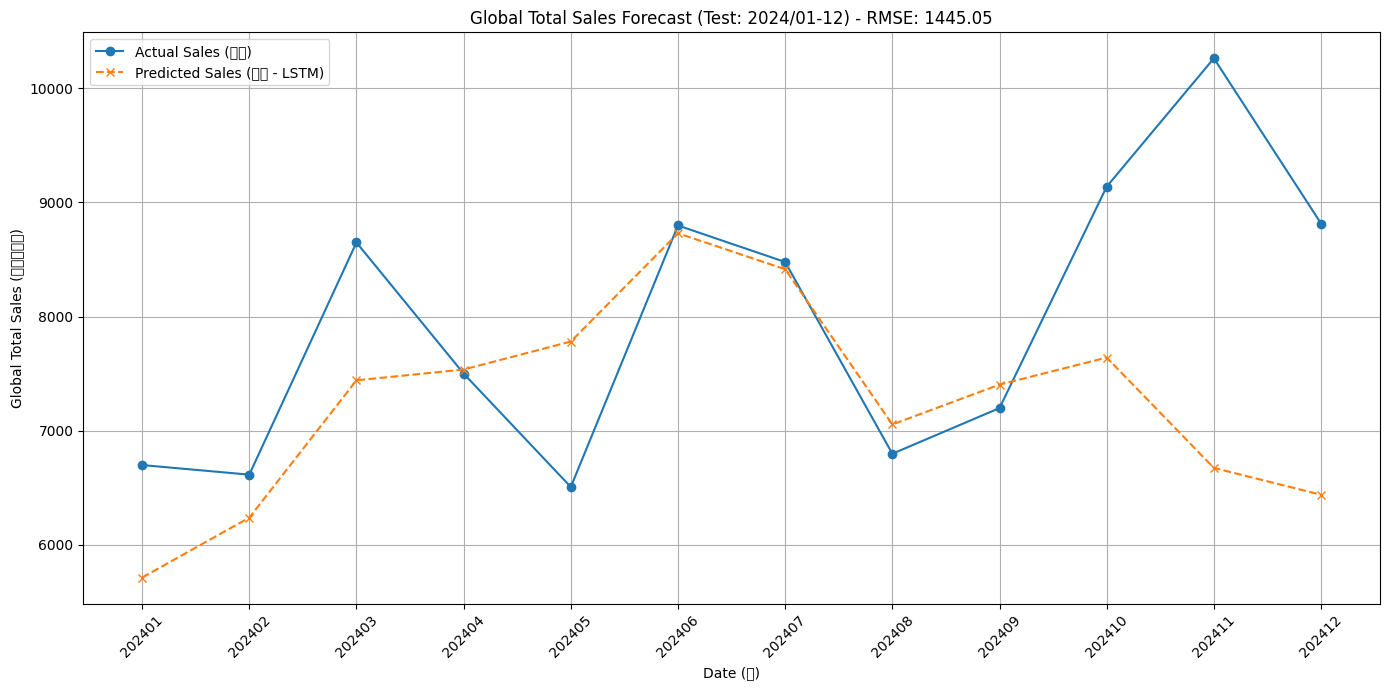

In [2]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------------------------------
# 0. 乱数シードの設定 (再現性の確保)
# ----------------------------------------------------
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# ----------------------------------------------------
# 1. PCA結果ファイルの読み込みとデータの前処理
# ----------------------------------------------------
input_file_name = '主成分分析_トヨタ全体.csv'
try:
    df_pca = pd.read_csv(input_file_name, encoding='utf_8_sig', index_col='date')
    df_pca.index = df_pca.index.astype(str)
except FileNotFoundError:
    print(f"エラー: ファイル '{input_file_name}' が見つかりません。予測を実行できません。")
    exit()

# --- 期間設定 ---
TIME_STEPS = 2 			 # ルックバック期間
TEST_START_DATE_PREDICT = '202401' # テスト期間開始 (予測ターゲット)
TEST_END_DATE_PREDICT = '202412'   # テスト期間終了 (予測ターゲット)

# 2024年12月までのデータのみを使用
df_filtered = df_pca[df_pca.index <= TEST_END_DATE_PREDICT].copy()

# 目的変数と特徴量の分離
target_column = 'Global_Total_Sales'
features = [col for col in df_filtered.columns if col.startswith('PC')]
X_data = df_filtered[features].values
y_data = df_filtered[target_column].values.reshape(-1, 1)

print(f"対象期間のデータ形状: {df_filtered.shape}")

# ----------------------------------------------------
# 2. LSTMモデルのためのデータ準備（スケーリングとシーケンス化）
# ----------------------------------------------------
# スケーリング
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_data)

# シーケンス化関数
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        # 入力X: iから i+time_steps までの特徴量（PC群）
        Xs.append(X[i:(i + time_steps), :])
        # 出力y: i+time_steps の時点の目的変数（Global_Total_Sales）
        ys.append(y[i + time_steps, 0])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)

# ----------------------------------------------------
# 3. 日付に基づいた訓練/テスト分割
# ----------------------------------------------------
# テスト開始日（202401）のインデックスを取得
test_start_df_index = df_filtered.index.get_loc(TEST_START_DATE_PREDICT)

# シーケンス化後のデータにおける訓練データのサイズ
train_sequence_size = test_start_df_index - TIME_STEPS

X_train, X_test = X_seq[:train_sequence_size], X_seq[train_sequence_size:]
y_train, y_test = y_seq[:train_sequence_size], y_seq[train_sequence_size:]

# 期間の確認
train_target_start = df_filtered.index[TIME_STEPS]
train_target_end = df_filtered.index[train_sequence_size + TIME_STEPS - 1] 
test_target_start = df_filtered.index[train_sequence_size + TIME_STEPS]
test_target_end = df_filtered.index[-1]


print(f"シーケンス化後の特徴量の形状: {X_seq.shape}")
print(f"🎯 訓練ターゲット期間: {train_target_start} 〜 {train_target_end}")
print(f"トレーニングシーケンス数: {len(X_train)}")
print(f"🎯 テストターゲット期間: {test_target_start} 〜 {test_target_end}")
print(f"テストシーケンス数: {len(X_test)}")
print("-" * 50)


# ----------------------------------------------------
# 4. LSTMモデルの構築と訓練 (学習率設定を追加) 🔧
# ----------------------------------------------------
# 学習率を定義する変数を追加
LEARNING_RATE = 0.001  # ⭐ ここで学習率を操作できます。デフォルトは0.001です。

# シード値を利用して重み初期化を固定
initializer = tf.keras.initializers.GlorotUniform(seed=SEED_VALUE)

model = Sequential([
    # 1層目: 次の層にシーケンスを渡すため return_sequences=True
    LSTM(200, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]),
          kernel_initializer=initializer, return_sequences=True),
    # 2層目: 次の層にシーケンスを渡すため return_sequences=True (input_shapeは不要)
    LSTM(190, activation='relu', kernel_initializer=initializer, return_sequences=True), 
    # 3層目: 次の層がDenseなので return_sequences=False (デフォルトなので省略)
    LSTM(190, activation='relu', kernel_initializer=initializer), 
    
    # 出力層
    Dense(1, kernel_initializer=initializer)
])

# オプティマイザのインスタンスを作成し、学習率を設定
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# 損失関数に Huber Loss を使用し、学習率を設定したオプティマイザを使用
model.compile(optimizer=optimizer_adam, loss='huber')

print(f"LSTMモデルの訓練を開始... (学習率: {LEARNING_RATE})")
history = model.fit(
    X_train, y_train,
    epochs=220, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=0, 
    shuffle=False
)
print("訓練完了。")
print("-" * 50)

# ----------------------------------------------------
# 5. 予測と評価、可視化
# ----------------------------------------------------
y_pred_scaled = model.predict(X_test, verbose=0)

# スケールを元に戻す
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 評価指標の計算
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

# MAPEの計算
mape_array = np.abs((y_test_actual - y_pred_actual) / y_test_actual)
mape = np.mean(mape_array[np.isfinite(mape_array)]) * 100
mape = mape if np.isfinite(mape) else np.nan

print(f"--- グローバル総販売台数予測性能評価 (テスト期間: {test_target_start} 〜 {test_target_end}) ---")
print(f"MAE (平均絶対誤差): {mae:.2f}")
print(f"RMSE (二乗平均平方根誤差): {rmse:.2f}")
print(f"MAPE (平均絶対パーセント誤差): {mape:.2f}%")

# 結果の可視化
test_dates = df_filtered.index[test_start_df_index:] 

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Sales (実績)', marker='o', linestyle='-')
plt.plot(test_dates, y_pred_actual, label='Predicted Sales (予測 - LSTM)', marker='x', linestyle='--')
plt.title(f'Global Total Sales Forecast (Test: 2024/01-12) - RMSE: {rmse:.2f}')
plt.xlabel('Date (月)')
plt.ylabel('Global Total Sales (総販売台数)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

対象期間のデータ形状: (60, 14)
シーケンス化後の特徴量の形状: (58, 2, 13)
🎯 訓練ターゲット期間: 202003 〜 202312
トレーニングシーケンス数: 46
🎯 テストターゲット期間: 202401 〜 202412
テストシーケンス数: 12
--------------------------------------------------


c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTMモデルの訓練を開始... (学習率: 0.001)
訓練完了。
--------------------------------------------------
--- グローバル総販売台数予測性能評価 (テスト期間: 202401 〜 202412) ---
MAE (平均絶対誤差): 994.25
RMSE (二乗平均平方根誤差): 1445.05
MAPE (平均絶対パーセント誤差): 11.74%
--------------------------------------------------
✅ 予測結果をファイル 'Toyota_Global_Sales_Forecast_Results.csv' に出力しました。
      date  Actual_Sales  Predicted_Sales
0   202401        6700.0      5714.810059
1   202402        6616.0      6239.020020
2   202403        8649.0      7442.129883
3   202404        7501.0      7536.479980
4   202405        6508.0      7781.500000
5   202406        8798.0      8729.700195
6   202407        8478.0      8414.620117
7   202408        6799.0      7055.819824
8   202409        7199.0      7404.549805
9   202410        9138.0      7641.209961
10  202411       10262.0      6674.839844
11  202412        8815.0      6440.000000
--------------------------------------------------


C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\3769974110.py:191: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\3769974110.py:191: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\3769974110.py:191: UserWarning: Glyph 36009 (\N{CJK UNIFIED IDEOGRAPH-8CA9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\3769974110.py:191: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\3769974110.py:191: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_12216\3769974110.py:191: UserWarning: Glyph 25

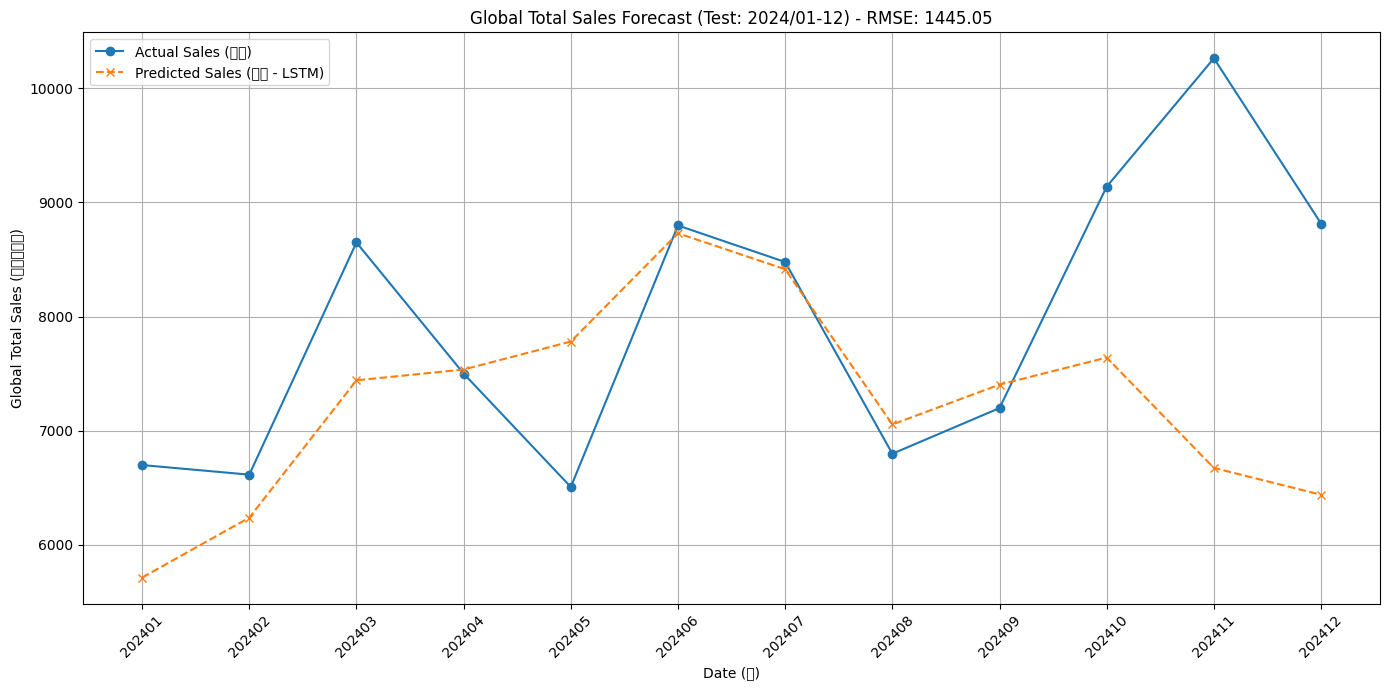

In [3]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------------------------------
# 0. 乱数シードの設定 (再現性の確保)
# ----------------------------------------------------
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# ----------------------------------------------------
# 1. PCA結果ファイルの読み込みとデータの前処理
# ----------------------------------------------------
input_file_name = '主成分分析_トヨタ全体.csv'
try:
    df_pca = pd.read_csv(input_file_name, encoding='utf_8_sig', index_col='date')
    df_pca.index = df_pca.index.astype(str)
except FileNotFoundError:
    print(f"エラー: ファイル '{input_file_name}' が見つかりません。予測を実行できません。")
    exit()

# --- 期間設定 ---
TIME_STEPS = 2             # ルックバック期間
TEST_START_DATE_PREDICT = '202401' # テスト期間開始 (予測ターゲット)
TEST_END_DATE_PREDICT = '202412'   # テスト期間終了 (予測ターゲット)

# 2024年12月までのデータのみを使用
df_filtered = df_pca[df_pca.index <= TEST_END_DATE_PREDICT].copy()

# 目的変数と特徴量の分離
target_column = 'Global_Total_Sales'
features = [col for col in df_filtered.columns if col.startswith('PC')]
X_data = df_filtered[features].values
y_data = df_filtered[target_column].values.reshape(-1, 1)

print(f"対象期間のデータ形状: {df_filtered.shape}")

# ----------------------------------------------------
# 2. LSTMモデルのためのデータ準備（スケーリングとシーケンス化）
# ----------------------------------------------------
# スケーリング
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_data)

# シーケンス化関数
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        # 入力X: iから i+time_steps までの特徴量（PC群）
        Xs.append(X[i:(i + time_steps), :])
        # 出力y: i+time_steps の時点の目的変数（Global_Total_Sales）
        ys.append(y[i + time_steps, 0])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)

# ----------------------------------------------------
# 3. 日付に基づいた訓練/テスト分割
# ----------------------------------------------------
# テスト開始日（202401）のインデックスを取得
test_start_df_index = df_filtered.index.get_loc(TEST_START_DATE_PREDICT)

# シーケンス化後のデータにおける訓練データのサイズ
train_sequence_size = test_start_df_index - TIME_STEPS

X_train, X_test = X_seq[:train_sequence_size], X_seq[train_sequence_size:]
y_train, y_test = y_seq[:train_sequence_size], y_seq[train_sequence_size:]

# 期間の確認
train_target_start = df_filtered.index[TIME_STEPS]
train_target_end = df_filtered.index[train_sequence_size + TIME_STEPS - 1] 
test_target_start = df_filtered.index[train_sequence_size + TIME_STEPS]
test_target_end = df_filtered.index[-1]


print(f"シーケンス化後の特徴量の形状: {X_seq.shape}")
print(f"🎯 訓練ターゲット期間: {train_target_start} 〜 {train_target_end}")
print(f"トレーニングシーケンス数: {len(X_train)}")
print(f"🎯 テストターゲット期間: {test_target_start} 〜 {test_target_end}")
print(f"テストシーケンス数: {len(X_test)}")
print("-" * 50)


# ----------------------------------------------------
# 4. LSTMモデルの構築と訓練 (学習率設定を追加) 🔧
# ----------------------------------------------------
# 学習率を定義する変数を追加
LEARNING_RATE = 0.001  # ⭐ ここで学習率を操作できます。デフォルトは0.001です。

# シード値を利用して重み初期化を固定
initializer = tf.keras.initializers.GlorotUniform(seed=SEED_VALUE)

model = Sequential([
    # 1層目: 次の層にシーケンスを渡すため return_sequences=True
    LSTM(200, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]),
          kernel_initializer=initializer, return_sequences=True),
    # 2層目: 次の層にシーケンスを渡すため return_sequences=True (input_shapeは不要)
    LSTM(190, activation='relu', kernel_initializer=initializer, return_sequences=True), 
    # 3層目: 次の層がDenseなので return_sequences=False (デフォルトなので省略)
    LSTM(190, activation='relu', kernel_initializer=initializer), 
    
    # 出力層
    Dense(1, kernel_initializer=initializer)
])

# オプティマイザのインスタンスを作成し、学習率を設定
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# 損失関数に Huber Loss を使用し、学習率を設定したオプティマイザを使用
model.compile(optimizer=optimizer_adam, loss='huber')

print(f"LSTMモデルの訓練を開始... (学習率: {LEARNING_RATE})")
history = model.fit(
    X_train, y_train,
    epochs=220, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=0, 
    shuffle=False
)
print("訓練完了。")
print("-" * 50)

# ----------------------------------------------------
# 5. 予測と評価
# ----------------------------------------------------
y_pred_scaled = model.predict(X_test, verbose=0)

# スケールを元に戻す
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 評価指標の計算
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

# MAPEの計算
mape_array = np.abs((y_test_actual - y_pred_actual) / y_test_actual)
mape = np.mean(mape_array[np.isfinite(mape_array) & (y_test_actual != 0)]) * 100
mape = mape if np.isfinite(mape) else np.nan

print(f"--- グローバル総販売台数予測性能評価 (テスト期間: {test_target_start} 〜 {test_target_end}) ---")
print(f"MAE (平均絶対誤差): {mae:.2f}")
print(f"RMSE (二乗平均平方根誤差): {rmse:.2f}")
print(f"MAPE (平均絶対パーセント誤差): {mape:.2f}%")

# ----------------------------------------------------
# 6. ★★★ 予測結果のCSVファイル出力処理を追加 ★★★
# ----------------------------------------------------
# テスト期間のインデックスを取得
# NOTE: df_filtered.index[test_start_df_index:] はシーケンス化前のインデックスなので、
# 実際に予測対象となっているインデックス（ターゲット期間）を使用
test_dates = df_filtered.index[train_sequence_size + TIME_STEPS:] 

# 結果をDataFrameに格納
output_df = pd.DataFrame({
    'date': test_dates,
    'Actual_Sales': y_test_actual.round(2), # 実績値 (小数点第2位まで)
    'Predicted_Sales': y_pred_actual.round(2) # 予測値 (小数点第2位まで)
})

output_file_name = 'Toyota_Global_Sales_Forecast_Results.csv'
output_df.to_csv(output_file_name, index=False, encoding='utf_8_sig')
print("-" * 50)
print(f"✅ 予測結果をファイル '{output_file_name}' に出力しました。")
print(output_df) 
print("-" * 50)

# ----------------------------------------------------
# 7. 可視化
# ----------------------------------------------------
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Sales (実績)', marker='o', linestyle='-')
plt.plot(test_dates, y_pred_actual, label='Predicted Sales (予測 - LSTM)', marker='x', linestyle='--')
plt.title(f'Global Total Sales Forecast (Test: 2024/01-12) - RMSE: {rmse:.2f}')
plt.xlabel('Date (月)')
plt.ylabel('Global Total Sales (総販売台数)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-11-10 14:56:27,365] A new study created in memory with name: no-name-0f1e414c-e55d-48a3-858b-900ef5c07557


シーケンス化後の特徴量の形状: (54, 6, 13)
🎯 訓練ターゲット期間: 202007 〜 202312
トレーニングシーケンス数: 42
🎯 テストターゲット期間: 202401 〜 202412
テストシーケンス数: 12
--------------------------------------------------
🚀 Optunaによるハイパーパラメータ最適化を開始...


  0%|          | 0/30 [00:00<?, ?it/s]C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:98: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 0.0100082:   3%|▎         | 1/30 [00:31<15:17, 31.63s/it]

[I 2025-11-10 14:56:58,991] Trial 0 finished with value: 0.010008243843913078 and parameters: {'lstm_units_1': 290, 'lstm_units_2': 350, 'lstm_units_3': 330, 'learning_rate': 0.0015751320499779737, 'epochs': 160}. Best is trial 0 with value: 0.010008243843913078.


Best trial: 0. Best value: 0.0100082:   7%|▋         | 2/30 [01:07<15:57, 34.20s/it]

...

Best trial: 26. Best value: 0.00978203:  97%|█████████▋| 29/30 [21:36<00:46, 46.52s/it]

[I 2025-11-10 15:18:04,163] Trial 28 finished with value: 0.009849605150520802 and parameters: {'lstm_units_1': 280, 'lstm_units_2': 310, 'lstm_units_3': 350, 'learning_rate': 0.003772137672526624, 'epochs': 200}. Best is trial 26 with value: 0.009782025590538979.


Best trial: 26. Best value: 0.00978203: 100%|██████████| 30/30 [22:16<00:00, 44.55s/it]


[I 2025-11-10 15:18:43,718] Trial 29 finished with value: 0.009857282042503357 and parameters: {'lstm_units_1': 280, 'lstm_units_2': 310, 'lstm_units_3': 330, 'learning_rate': 0.004394567473369966, 'epochs': 180}. Best is trial 26 with value: 0.009782025590538979.

--- Optuna 最適化結果 ---
最適試行回数: 26
最小検証損失 (val_loss): 0.009782
最適なハイパーパラメータ:
  lstm_units_1: 290
  lstm_units_2: 290
  lstm_units_3: 340
  learning_rate: 0.004296061956711406
  epochs: 190
--------------------------------------------------
最適なハイパーパラメータで最終モデルの訓練を開始...
最終モデル訓練完了。 (学習率: 0.004296, エポック: 190)

--- 最終モデル グローバル総販売台数予測性能評価 (テスト期間: 202401 〜 202412) ---
MAE (平均絶対誤差): 1720.68
RMSE (二乗平均平方根誤差): 2027.67
MAPE (平均絶対パーセント誤差): 20.48%


C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:225: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:225: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:225: UserWarning: Glyph 36009 (\N{CJK UNIFIED IDEOGRAPH-8CA9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:225: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:225: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_14712\1727369445.py:225: UserWarning: Glyph 25

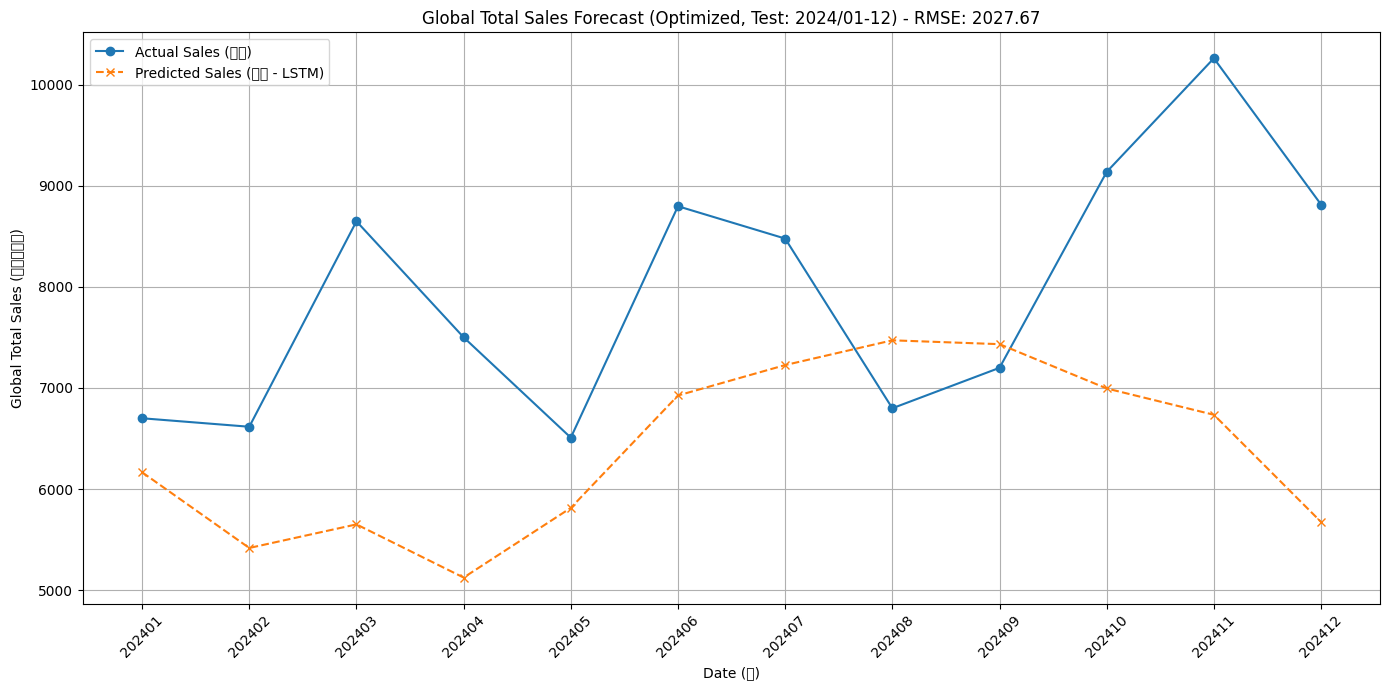

In [63]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ⭐ Optunaライブラリをインポート
import optuna 
from optuna.samplers import TPESampler

# ----------------------------------------------------
# 0. 乱数シードの設定 (再現性の確保)
# ----------------------------------------------------
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# ----------------------------------------------------
# 1. PCA結果ファイルの読み込みとデータの前処理 (前回と同じ)
# ----------------------------------------------------
input_file_name = '主成分分析_トヨタ全体.csv'
try:
    df_pca = pd.read_csv(input_file_name, encoding='utf_8_sig', index_col='date')
    df_pca.index = df_pca.index.astype(str)
except FileNotFoundError:
    print(f"エラー: ファイル '{input_file_name}' が見つかりません。予測を実行できません。")
    exit()

# --- 期間設定 ---
TIME_STEPS = 6 			 # ルックバック期間
TEST_START_DATE_PREDICT = '202401' # テスト期間開始 (予測ターゲット)
TEST_END_DATE_PREDICT = '202412'   # テスト期間終了 (予測ターゲット)

df_filtered = df_pca[df_pca.index <= TEST_END_DATE_PREDICT].copy()
target_column = 'Global_Total_Sales'
features = [col for col in df_filtered.columns if col.startswith('PC')]
X_data = df_filtered[features].values
y_data = df_filtered[target_column].values.reshape(-1, 1)

# ----------------------------------------------------
# 2. LSTMモデルのためのデータ準備（スケーリングとシーケンス化）
# ----------------------------------------------------
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_data)

# シーケンス化関数 (変更なし)
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps), :])
        ys.append(y[i + time_steps, 0])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)

# ----------------------------------------------------
# 3. 日付に基づいた訓練/テスト分割 (変更なし)
# ----------------------------------------------------
test_start_df_index = df_filtered.index.get_loc(TEST_START_DATE_PREDICT)
train_sequence_size = test_start_df_index - TIME_STEPS

X_train, X_test = X_seq[:train_sequence_size], X_seq[train_sequence_size:]
y_train, y_test = y_seq[:train_sequence_size], y_seq[train_sequence_size:]

# 期間の確認 (出力用)
train_target_start = df_filtered.index[TIME_STEPS]
train_target_end = df_filtered.index[train_sequence_size + TIME_STEPS - 1] 
test_target_start = df_filtered.index[train_sequence_size + TIME_STEPS]
test_target_end = df_filtered.index[-1]


print(f"シーケンス化後の特徴量の形状: {X_seq.shape}")
print(f"🎯 訓練ターゲット期間: {train_target_start} 〜 {train_target_end}")
print(f"トレーニングシーケンス数: {len(X_train)}")
print(f"🎯 テストターゲット期間: {test_target_start} 〜 {test_target_end}")
print(f"テストシーケンス数: {len(X_test)}")
print("-" * 50)


# ----------------------------------------------------
# 4. Optuna最適化の目的関数 (Objective Function) の定義 ⭐
# ----------------------------------------------------
def objective(trial):
    # --- 1. ハイパーパラメータの探索範囲を定義 ---
    # LSTMユニット数 (3層)
    lstm_units_1 = trial.suggest_int('lstm_units_1', 250, 350, step=10)
    lstm_units_2 = trial.suggest_int('lstm_units_2', 250, 350, step=10)
    lstm_units_3 = trial.suggest_int('lstm_units_3', 250, 350, step=10)
    
    # 学習率 (対数スケールで探索)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    
    # エポック数 (訓練時間節約のため範囲を狭めることも可能)
    epochs = trial.suggest_int('epochs', 150, 250, step=10)
    
    # バッチサイズ (計算効率のため固定することが多い)
    batch_size = 32 # trial.suggest_categorical('batch_size', [32, 64])

    # --- 2. モデル構築 ---
    initializer = tf.keras.initializers.GlorotUniform(seed=SEED_VALUE)

    model = Sequential([
        LSTM(lstm_units_1, activation='relu', 
             input_shape=(X_train.shape[1], X_train.shape[2]),
             kernel_initializer=initializer, return_sequences=True),
        LSTM(lstm_units_2, activation='relu', 
             kernel_initializer=initializer, return_sequences=True), 
        LSTM(lstm_units_3, activation='relu', 
             kernel_initializer=initializer), 
        Dense(1, kernel_initializer=initializer)
    ])

    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adam, loss='huber')

    # --- 3. モデル訓練 ---
    # 検証データでの性能を評価するため、validation_splitを使用
    history = model.fit(
        X_train, y_train,
        epochs=epochs, 
        batch_size=batch_size, 
        validation_split=0.1,  # 訓練データの10%を検証に使用
        verbose=0, 
        shuffle=False
    )
    
    # --- 4. 目的変数の返却 ---
    # Optunaは目的関数を最小化しようとするため、検証データの最終的な損失を返す
    # 'val_loss' は検証データセットでのHuber Loss
    best_validation_loss = min(history.history['val_loss'])
    return best_validation_loss

# ----------------------------------------------------
# 5. Optunaによる最適化の実行 ⭐
# ----------------------------------------------------
print("🚀 Optunaによるハイパーパラメータ最適化を開始...")
# TPESampler (ベイズ最適化) を使用
sampler = TPESampler(seed=SEED_VALUE) 
study = optuna.create_study(direction='minimize', sampler=sampler)

# 試行回数を設定
N_TRIALS = 30  # 実行時間に応じてこの値を調整してください

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n--- Optuna 最適化結果 ---")
print(f"最適試行回数: {study.best_trial.number}")
print(f"最小検証損失 (val_loss): {study.best_value:.6f}")
print("最適なハイパーパラメータ:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")

# ----------------------------------------------------
# 6. 最適パラメータで最終モデルを構築・訓練・評価 ⭐
# ----------------------------------------------------
print("-" * 50)
print("最適なハイパーパラメータで最終モデルの訓練を開始...")

# 最終モデル構築のための最適なパラメータ
FINAL_LR = best_params['learning_rate']
FINAL_EPOCHS = best_params['epochs']
FINAL_UNITS_1 = best_params['lstm_units_1']
FINAL_UNITS_2 = best_params['lstm_units_2']
FINAL_UNITS_3 = best_params['lstm_units_3']

# 最終モデルの構築
initializer = tf.keras.initializers.GlorotUniform(seed=SEED_VALUE)
model = Sequential([
    LSTM(FINAL_UNITS_1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]),
          kernel_initializer=initializer, return_sequences=True),
    LSTM(FINAL_UNITS_2, activation='relu', kernel_initializer=initializer, return_sequences=True), 
    LSTM(FINAL_UNITS_3, activation='relu', kernel_initializer=initializer), 
    Dense(1, kernel_initializer=initializer)
])

optimizer_adam = tf.keras.optimizers.Adam(learning_rate=FINAL_LR)
model.compile(optimizer=optimizer_adam, loss='huber')

history = model.fit(
    X_train, y_train,
    epochs=FINAL_EPOCHS, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=0, 
    shuffle=False
)
print(f"最終モデル訓練完了。 (学習率: {FINAL_LR:.6f}, エポック: {FINAL_EPOCHS})")

# 予測と評価
y_pred_scaled = model.predict(X_test, verbose=0)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled).flatten()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape_array = np.abs((y_test_actual - y_pred_actual) / y_test_actual)
mape = np.mean(mape_array[np.isfinite(mape_array)]) * 100
mape = mape if np.isfinite(mape) else np.nan

print(f"\n--- 最終モデル グローバル総販売台数予測性能評価 (テスト期間: {test_target_start} 〜 {test_target_end}) ---")
print(f"MAE (平均絶対誤差): {mae:.2f}")
print(f"RMSE (二乗平均平方根誤差): {rmse:.2f}")
print(f"MAPE (平均絶対パーセント誤差): {mape:.2f}%")

# 結果の可視化
test_dates = df_filtered.index[test_start_df_index:] 

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Sales (実績)', marker='o', linestyle='-')
plt.plot(test_dates, y_pred_actual, label='Predicted Sales (予測 - LSTM)', marker='x', linestyle='--')
plt.title(f'Global Total Sales Forecast (Optimized, Test: 2024/01-12) - RMSE: {rmse:.2f}')
plt.xlabel('Date (月)')
plt.ylabel('Global Total Sales (総販売台数)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[I 2025-11-11 00:38:50,341] A new study created in memory with name: no-name-06b2f3b0-a423-4271-8bcb-858042f791f5


シーケンス化後の特徴量の形状: (54, 6, 13)
🎯 訓練ターゲット期間: 202007 〜 202312
トレーニングシーケンス数 (Optuna): 38
検証シーケンス数 (Optuna): 4
🎯 テストターゲット期間: 202401 〜 202412
--------------------------------------------------
🚀 Optunaによるハイパーパラメータ最適化を開始 (目的: MAPE最小化)...


  0%|          | 0/30 [00:00<?, ?it/s]C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:101: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 44.7653:   3%|▎         | 1/30 [00:24<11:55, 24.67s/it]C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:101: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/rele

[I 2025-11-11 00:39:14,994] Trial 0 finished with value: 44.765274989806024 and parameters: {'lstm_units_1': 190, 'lstm_units_2': 340, 'lstm_units_3': 270, 'learning_rate': 0.0015751320499779737, 'epochs': 160}. Best is trial 0 with value: 44.765274989806024.


Best trial: 1. Best value: 34.9611:   7%|▋         | 2/30 [00:55<13:06, 28.09s/it]C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:101: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Best trial: 6. Best value: 24.2456:  97%|█████████▋| 29/30 [13:46<00:27, 27.03s/it]C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:101: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[I 2025-11-11 00:52:36,438] Trial 28 finished with value: 42.16766302943052 and parameters: {'lstm_units_1': 190, 'lstm_units_2': 180, 'lstm_units_3': 80, 'learning_rate': 0.001009623999743345, 'epochs': 240}. Best is trial 6 with value: 24.245600127360948.


Best trial: 6. Best value: 24.2456: 100%|██████████| 30/30 [14:11<00:00, 28.40s/it]
c:\Users\ciao0\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[I 2025-11-11 00:53:02,191] Trial 29 finished with value: 32.96017054954917 and parameters: {'lstm_units_1': 220, 'lstm_units_2': 320, 'lstm_units_3': 120, 'learning_rate': 0.005814009904810428, 'epochs': 180}. Best is trial 6 with value: 24.245600127360948.

--- Optuna 最適化結果 ---
最適試行回数: 6
最小MAPE (検証データ): 24.25%
最適なハイパーパラメータ:
  lstm_units_1: 250
  lstm_units_2: 120
  lstm_units_3: 70
  learning_rate: 0.007902619549708232
  epochs: 250
--------------------------------------------------
最適なハイパーパラメータで最終モデルの訓練を開始...
最終モデル訓練完了。 (学習率: 0.007903, エポック: 250)

--- 最終モデル グローバル総販売台数予測性能評価 (テスト期間: 202401 〜 202412) ---
MAE (平均絶対誤差): 1247.01
RMSE (二乗平均平方根誤差): 1619.72
MAPE (平均絶対パーセント誤差): 14.20%
--------------------------------------------------
📅 月次グローバル総販売台数予測結果 (2024年)
|   Date |   Actual_Sales |   Predicted_Sales |   Error (Actual - Predicted) |   MAPE (%) |
|-------:|---------------:|------------------:|-----------------------------:|-----------:|
| 202401 |           6700 |              7047 |   

C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:248: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:248: UserWarning: Glyph 32207 (\N{CJK UNIFIED IDEOGRAPH-7DCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:248: UserWarning: Glyph 36009 (\N{CJK UNIFIED IDEOGRAPH-8CA9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:248: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:248: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ciao0\AppData\Local\Temp\ipykernel_44100\4272660935.py:248: UserWarning: Glyph 25

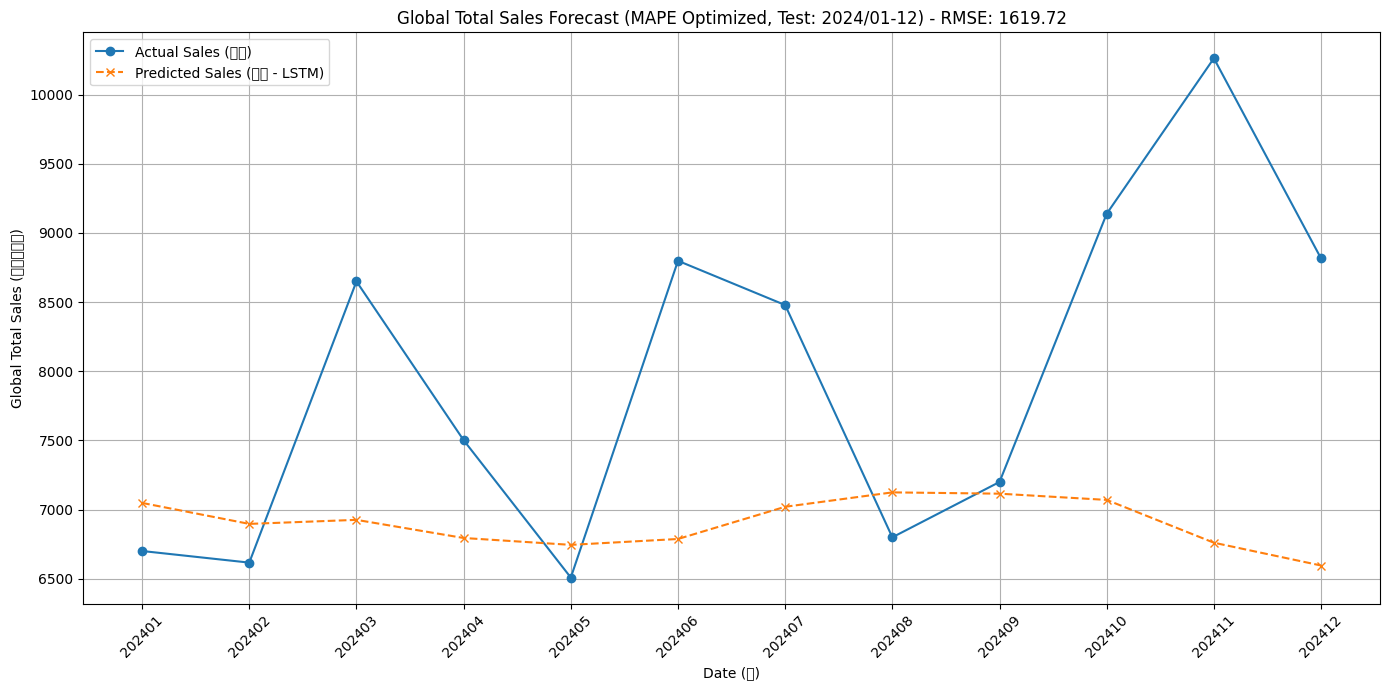

In [2]:
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ⭐ Optunaライブラリをインポート
import optuna 
from optuna.samplers import TPESampler

# ----------------------------------------------------
# 0. 乱数シードの設定 (再現性の確保)
# ----------------------------------------------------
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# ----------------------------------------------------
# 1. PCA結果ファイルの読み込みとデータの前処理
# ----------------------------------------------------
input_file_name = '主成分分析_トヨタ全体.csv'
try:
    df_pca = pd.read_csv(input_file_name, encoding='utf_8_sig', index_col='date')
    df_pca.index = df_pca.index.astype(str)
except FileNotFoundError:
    print(f"エラー: ファイル '{input_file_name}' が見つかりません。予測を実行できません。")
    exit()

# --- 期間設定 ---
TIME_STEPS = 6 			 # ルックバック期間
TEST_START_DATE_PREDICT = '202401' # テスト期間開始 (予測ターゲット)
TEST_END_DATE_PREDICT = '202412'   # テスト期間終了 (予測ターゲット)

df_filtered = df_pca[df_pca.index <= TEST_END_DATE_PREDICT].copy()
target_column = 'Global_Total_Sales'
features = [col for col in df_filtered.columns if col.startswith('PC')]
X_data = df_filtered[features].values
y_data = df_filtered[target_column].values.reshape(-1, 1)

# ----------------------------------------------------
# 2. LSTMモデルのためのデータ準備（スケーリングとシーケンス化）
# ----------------------------------------------------
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_data)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y_data)

# シーケンス化関数
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps), :])
        ys.append(y[i + time_steps, 0])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)

# ----------------------------------------------------
# 3. 日付に基づいた訓練/テスト分割
# ----------------------------------------------------
test_start_df_index = df_filtered.index.get_loc(TEST_START_DATE_PREDICT)
train_sequence_size = test_start_df_index - TIME_STEPS

X_train, X_test = X_seq[:train_sequence_size], X_seq[train_sequence_size:]
y_train, y_test = y_seq[:train_sequence_size], y_seq[train_sequence_size:]

# 検証データセットを分離
VALIDATION_SPLIT = 0.1
val_size = int(len(X_train) * VALIDATION_SPLIT)
X_train_optuna, X_val_optuna = X_train[:-val_size], X_train[-val_size:]
y_train_optuna, y_val_optuna = y_train[:-val_size], y_train[-val_size:]

# 期間の確認 (出力用)
train_target_start = df_filtered.index[TIME_STEPS]
train_target_end = df_filtered.index[train_sequence_size + TIME_STEPS - 1] 
test_target_start = df_filtered.index[train_sequence_size + TIME_STEPS]
test_target_end = df_filtered.index[-1]


print(f"シーケンス化後の特徴量の形状: {X_seq.shape}")
print(f"🎯 訓練ターゲット期間: {train_target_start} 〜 {train_target_end}")
print(f"トレーニングシーケンス数 (Optuna): {len(X_train_optuna)}")
print(f"検証シーケンス数 (Optuna): {len(X_val_optuna)}")
print(f"🎯 テストターゲット期間: {test_target_start} 〜 {test_target_end}")
print("-" * 50)


# ----------------------------------------------------
# 4. Optuna最適化の目的関数 (MAPE最小化) 
# ----------------------------------------------------
def objective(trial):
    # --- 1. ハイパーパラメータの探索範囲を定義 ---
    lstm_units_1 = trial.suggest_int('lstm_units_1', 100, 350, step=10)
    lstm_units_2 = trial.suggest_int('lstm_units_2', 80, 350, step=10)
    lstm_units_3 = trial.suggest_int('lstm_units_3', 60, 350, step=10)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    epochs = trial.suggest_int('epochs', 150, 250, step=10)
    batch_size = 32

    # --- 2. モデル構築 ---
    initializer = tf.keras.initializers.GlorotUniform(seed=SEED_VALUE)

    model = Sequential([
        LSTM(lstm_units_1, activation='relu', 
             input_shape=(X_train.shape[1], X_train.shape[2]),
             kernel_initializer=initializer, return_sequences=True),
        LSTM(lstm_units_2, activation='relu', 
             kernel_initializer=initializer, return_sequences=True), 
        LSTM(lstm_units_3, activation='relu', 
             kernel_initializer=initializer), 
        Dense(1, kernel_initializer=initializer)
    ])

    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer_adam, loss='huber')

    # --- 3. モデル訓練 ---
    model.fit(
        X_train_optuna, y_train_optuna,
        epochs=epochs, 
        batch_size=batch_size, 
        validation_data=(X_val_optuna, y_val_optuna),
        verbose=0, 
        shuffle=False
    )
    
    # --- 4. 検証データでMAPEを計算し、返却 ---
    y_pred_scaled_val = model.predict(X_val_optuna, verbose=0)
    
    y_val_actual = scaler_y.inverse_transform(y_val_optuna.reshape(-1, 1)).flatten()
    y_pred_actual_val = scaler_y.inverse_transform(y_pred_scaled_val).flatten()

    mape_array = np.abs((y_val_actual - y_pred_actual_val) / y_val_actual)
    mape = np.mean(mape_array[np.isfinite(mape_array)]) * 100
    mape = mape if np.isfinite(mape) else np.nan
    
    return mape

# ----------------------------------------------------
# 5. Optunaによる最適化の実行
# ----------------------------------------------------
print("🚀 Optunaによるハイパーパラメータ最適化を開始 (目的: MAPE最小化)...")
sampler = TPESampler(seed=SEED_VALUE) 
study = optuna.create_study(direction='minimize', sampler=sampler)

N_TRIALS = 30  # 実行時間に応じてこの値を調整してください

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n--- Optuna 最適化結果 ---")
print(f"最適試行回数: {study.best_trial.number}")
print(f"最小MAPE (検証データ): {study.best_value:.2f}%")
print("最適なハイパーパラメータ:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")

# ----------------------------------------------------
# 6. 最適パラメータで最終モデルを構築・訓練・評価
# ----------------------------------------------------
print("-" * 50)
print("最適なハイパーパラメータで最終モデルの訓練を開始...")

# 最終モデル構築のための最適なパラメータ
FINAL_LR = best_params['learning_rate']
FINAL_EPOCHS = best_params['epochs']
FINAL_UNITS_1 = best_params['lstm_units_1']
FINAL_UNITS_2 = best_params['lstm_units_2']
FINAL_UNITS_3 = best_params['lstm_units_3']

# 最終モデルの構築
initializer = tf.keras.initializers.GlorotUniform(seed=SEED_VALUE)
model = Sequential([
    LSTM(FINAL_UNITS_1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]),
          kernel_initializer=initializer, return_sequences=True),
    LSTM(FINAL_UNITS_2, activation='relu', kernel_initializer=initializer, return_sequences=True), 
    LSTM(FINAL_UNITS_3, activation='relu', kernel_initializer=initializer), 
    Dense(1, kernel_initializer=initializer)
])

optimizer_adam = tf.keras.optimizers.Adam(learning_rate=FINAL_LR)
model.compile(optimizer=optimizer_adam, loss='huber')

# 訓練データ全体 (X_train, y_train) で最終訓練
model.fit(
    X_train, y_train,
    epochs=FINAL_EPOCHS, 
    batch_size=32, 
    validation_split=VALIDATION_SPLIT,
    verbose=0, 
    shuffle=False
)
print(f"最終モデル訓練完了。 (学習率: {FINAL_LR:.6f}, エポック: {FINAL_EPOCHS})")

# 予測と評価 (テストデータX_testに対して行う)
y_pred_scaled = model.predict(X_test, verbose=0)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 評価指標の計算
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape_array = np.abs((y_test_actual - y_pred_actual) / y_test_actual)
mape = np.mean(mape_array[np.isfinite(mape_array)]) * 100
mape = mape if np.isfinite(mape) else np.nan

print(f"\n--- 最終モデル グローバル総販売台数予測性能評価 (テスト期間: {test_target_start} 〜 {test_target_end}) ---")
print(f"MAE (平均絶対誤差): {mae:.2f}")
print(f"RMSE (二乗平均平方根誤差): {rmse:.2f}")
print(f"MAPE (平均絶対パーセント誤差): {mape:.2f}%")
print("-" * 50)

# ⭐ 予測結果の月次数値表示 ⭐
test_dates = df_filtered.index[test_start_df_index:] 

results_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Sales': y_test_actual.round(2),
    'Predicted_Sales': y_pred_actual.round(2),
    'Error (Actual - Predicted)': (y_test_actual - y_pred_actual).round(2),
    'MAPE (%)': (np.abs(y_test_actual - y_pred_actual) / y_test_actual * 100).round(2)
})
results_df['Predicted_Sales'] = results_df['Predicted_Sales'].astype(int)
results_df['Actual_Sales'] = results_df['Actual_Sales'].astype(int)
results_df['Error (Actual - Predicted)'] = results_df['Error (Actual - Predicted)'].astype(int)


print("📅 月次グローバル総販売台数予測結果 (2024年)")
print(results_df.to_markdown(index=False))
print("-" * 50)


# 結果の可視化
plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_actual, label='Actual Sales (実績)', marker='o', linestyle='-')
plt.plot(test_dates, y_pred_actual, label='Predicted Sales (予測 - LSTM)', marker='x', linestyle='--')
plt.title(f'Global Total Sales Forecast (MAPE Optimized, Test: 2024/01-12) - RMSE: {rmse:.2f}')
plt.xlabel('Date (月)')
plt.ylabel('Global Total Sales (総販売台数)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()